In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from causalml.inference.meta import (
    BaseSRegressor,
    BaseTRegressor,
    BaseXRegressor,
    BaseRRegressor,
    BaseDRRegressor
)

from causalml.metrics import (
    qini_score,
    auuc_score,
    plot_qini
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
pip install causalml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 19.1 MB/s eta 0:00:00
  Created wheel for causalml: filename=causalml-0.17.0-cp313-cp313-linux_x86_64.whl size=8776098 sha256=670eed1166251d1d06000e92e443275aff53df9347cf169a0fb7955047bd7ace
  Stored in directory: /root/.cache/pip/wheels/39/f5/86/1ce20c63eba1929d0ebec5abbf113145c1ff0002d51da669c4
Successfully built causalml


Dataset shape: (3910000, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.960515,4.679882,11.561050,4.115453,0.294443,4.833815,3.813437,13.190056,6.372805,-0.168679,1,0,0,0
1,18.065406,10.059654,8.214383,3.907662,10.280525,4.115453,-1.288207,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
2,24.597845,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0
3,12.616365,10.059654,8.946344,4.679882,10.280525,4.115453,0.294443,4.833815,3.874503,13.190056,5.300375,-0.168679,1,0,0,0
4,22.457720,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,1,0,0,0


Features:
['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']

Treatment column:
treatment

Outcome column:
conversion

Columns intentionally NOT used as features:
['visit', 'exposure']
Modeling dataset shape: (500000, 16)

Missing values:
f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
dtype: int64

Treatment distribution:
treatment
1    0.685814
0    0.314186
Name: proportion, dtype: float64

Outcome distribution:
conversion
0    0.996662
1    0.003338
Name: proportion, dtype: float64

Conversion rate by treatment:
               mean   count
treatment                  
0          0.003157  157093
1          0.003421  342907

X shape: (500000, 12)
Treatment rate: 0.685814
Conversion rate: 0.003338

Train shape: (350000, 12)
Test shape : (150000, 12)

Train treatment rate: 0.68581428571428

,treatment,conversion,S_Learner,T_Learner,X_Learner,R_Learner,DR_Learner
0,1,0,0.0,0.000061,0.000020,-0.000003,-0.000018
1,1,0,0.0,0.000061,0.000020,-0.000003,-0.000018
2,1,0,0.0,-0.000049,0.000013,-0.000003,-0.000061
3,1,0,0.0,0.007114,0.004607,0.007058,0.004242
4,1,0,0.0,-0.002514,-0.002566,0.003687,-0.001343




MEAN CATE COMPARISON


...

,count,mean,std,min,25%,50%,75%,max
S_Learner,150000.0,0.000170,0.002752,-0.042548,0.000000,0.000000,0.000000,0.152362
T_Learner,150000.0,0.000352,0.014694,-0.664073,-0.000012,0.000061,0.000061,0.764812
X_Learner,150000.0,0.000370,0.011160,-0.533667,0.000013,0.000013,0.000020,0.700675
R_Learner,150000.0,0.000379,0.014941,-0.918348,-0.000003,-0.000003,-0.000003,1.035607
DR_Learner,150000.0,0.000256,0.014884,-0.737283,-0.000061,-0.000018,-0.000018,0.734601




QINI SCORES


,0
X_Learner,0.436092
S_Learner,0.075605
DR_Learner,0.048282
T_Learner,-0.268607
R_Learner,-0.356554




AUUC SCORES


,0
X_Learner,0.949205
S_Learner,0.576542
DR_Learner,0.562528
T_Learner,0.246620
R_Learner,0.145283


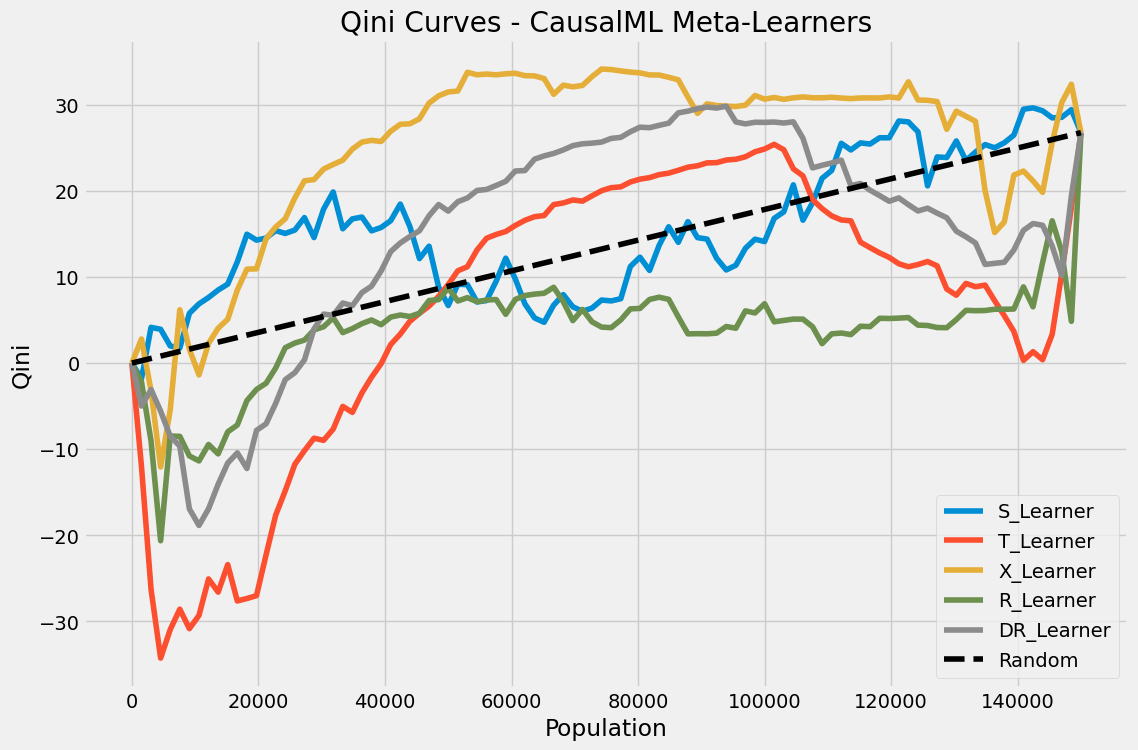



TOP 20% TARGETING VALIDATION


,Model,Top 20% Treated Conversion,Top 20% Control Conversion,Top 20% Observed Uplift,Overall Observed ATE
2,X_Learner,0.009821,0.008717,0.001104,0.00026
0,S_Learner,0.010888,0.010086,0.000801,0.00026
4,DR_Learner,0.009611,0.009358,0.000253,0.00026
3,R_Learner,0.009836,0.009614,0.000221,0.00026
1,T_Learner,0.009341,0.009759,-0.000418,0.00026




BOTTOM 20% TARGETING VALIDATION


,Model,Bottom 20% Observed Uplift,Overall Observed ATE
0,S_Learner,0.000032,0.00026
1,T_Learner,-0.000311,0.00026
2,X_Learner,-0.001167,0.00026
3,R_Learner,0.000785,0.00026
4,DR_Learner,-0.000665,0.00026




TOP 20% VS BOTTOM 20%


,Model,Top 20% Observed Uplift,Bottom 20% Observed Uplift,Top-Bottom Difference
2,X_Learner,0.001104,-0.001167,0.002271
4,DR_Learner,0.000253,-0.000665,0.000917
0,S_Learner,0.000801,0.000032,0.000770
1,T_Learner,-0.000418,-0.000311,-0.000108
3,R_Learner,0.000221,0.000785,-0.000564




FINAL META-LEARNER COMPARISON


,Model,Mean Predicted CATE,Observed ATE,Qini Score,AUUC Score
0,S-Learner,0.000170,0.00026,0.075605,0.576542
1,T-Learner,0.000352,0.00026,-0.268607,0.246620
2,X-Learner,0.000370,0.00026,0.436092,0.949205
3,R-Learner,0.000379,0.00026,-0.356554,0.145283
4,DR-Learner,0.000256,0.00026,0.048282,0.562528


In [4]:
# ============================================================
# META-LEARNERS USING CAUSALML
# Dataset: Criteo Uplift Prediction Dataset
#
# Meta-Learners:
# 1. S-Learner
# 2. T-Learner
# 3. X-Learner
# 4. R-Learner
# 5. DR-Learner
#
# Treatment : treatment
# Outcome   : conversion
# Features  : f0 - f11
#
# visit and exposure are NOT used as model features.
# ============================================================


# ============================================================
# 0. INSTALLATION
# Run once if required
# ============================================================

# %pip install -q causalml xgboost


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

from causalml.inference.meta import (
    BaseSRegressor,
    BaseTRegressor,
    BaseXRegressor,
    BaseRRegressor,
    BaseDRRegressor
)

from causalml.metrics import (
    qini_score,
    auuc_score,
    plot_qini
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ============================================================
# 2. LOAD CRITEO DATASET
# ============================================================

# Update the path according to your dataset location
df = pd.read_parquet('./drive/MyDrive/Untitledfolder/0001.parquet')

print("Dataset shape:", df.shape)

display(df.head())


# ============================================================
# 3. DATASET FEATURES
# ============================================================

FEATURES = [
    "f0",
    "f1",
    "f2",
    "f3",
    "f4",
    "f5",
    "f6",
    "f7",
    "f8",
    "f9",
    "f10",
    "f11"
]

TREATMENT_COL = "treatment"
OUTCOME_COL = "conversion"


print("Features:")
print(FEATURES)

print("\nTreatment column:")
print(TREATMENT_COL)

print("\nOutcome column:")
print(OUTCOME_COL)

print("\nColumns intentionally NOT used as features:")
print(["visit", "exposure"])


# ============================================================
# 4. OPTIONAL SAMPLING
# ============================================================
#
# Criteo is a very large dataset.
#
# During development, using 500K observations makes experiments
# much faster.
#
# Set:
#
# SAMPLE_SIZE = None
#
# if you want to train on the complete dataset.
# ============================================================

SAMPLE_SIZE = 500_000


if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:

    df_model = df.sample(
        n=SAMPLE_SIZE,
        random_state=RANDOM_STATE
    ).copy()

else:

    df_model = df.copy()


print("Modeling dataset shape:", df_model.shape)


# ============================================================
# 5. BASIC DATA CHECKS
# ============================================================

print("\nMissing values:")
print(
    df_model[
        FEATURES + [TREATMENT_COL, OUTCOME_COL]
    ].isnull().sum()
)


print("\nTreatment distribution:")
print(
    df_model[TREATMENT_COL].value_counts(normalize=True)
)


print("\nOutcome distribution:")
print(
    df_model[OUTCOME_COL].value_counts(normalize=True)
)


print("\nConversion rate by treatment:")
print(
    df_model
    .groupby(TREATMENT_COL)[OUTCOME_COL]
    .agg(["mean", "count"])
)


# ============================================================
# 6. CREATE X, T AND Y
# ============================================================

X = df_model[FEATURES].astype("float32")

T = df_model[TREATMENT_COL].astype("int8")

Y = df_model[OUTCOME_COL].astype("int8")


print("\nX shape:", X.shape)
print("Treatment rate:", T.mean())
print("Conversion rate:", Y.mean())


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================
#
# We stratify using both treatment and outcome because
# conversion is rare in Criteo.
# ============================================================

strata = (
    T.astype(str)
    + "_"
    + Y.astype(str)
)


X_train, X_test, T_train, T_test, Y_train, Y_test = train_test_split(
    X,
    T,
    Y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=strata
)


# Reset indexes
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

T_train = T_train.reset_index(drop=True)
T_test = T_test.reset_index(drop=True)

Y_train = Y_train.reset_index(drop=True)
Y_test = Y_test.reset_index(drop=True)


print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nTrain treatment rate:", T_train.mean())
print("Test treatment rate :", T_test.mean())

print("\nTrain conversion rate:", Y_train.mean())
print("Test conversion rate :", Y_test.mean())


# ============================================================
# 8. OBSERVED EXPERIMENTAL ATE
# ============================================================
#
# Since Criteo comes from randomized treatment assignment,
# difference in observed conversion rates gives us an important
# benchmark.
#
# ATE =
#
# P(Y=1 | T=1)
#       -
# P(Y=1 | T=0)
# ============================================================

treated_conversion = Y_test[T_test == 1].mean()

control_conversion = Y_test[T_test == 0].mean()

observed_ate = (
    treated_conversion
    -
    control_conversion
)


print("\n========== OBSERVED EXPERIMENT ==========")

print(
    f"Treated conversion rate : "
    f"{treated_conversion:.6f}"
)

print(
    f"Control conversion rate : "
    f"{control_conversion:.6f}"
)

print(
    f"Observed ATE             : "
    f"{observed_ate:.6f}"
)


# ============================================================
# 9. PROPENSITY SCORE
# ============================================================
#
# Criteo treatment is randomized.
#
# Therefore:
#
# e(X) = P(T=1 | X)
#
# does not need to be estimated using another ML model.
#
# We use the observed treatment assignment probability from
# the training dataset as the constant propensity.
# ============================================================

treatment_probability = T_train.mean()


p_train = np.full(
    len(X_train),
    treatment_probability,
    dtype="float32"
)


p_test = np.full(
    len(X_test),
    treatment_probability,
    dtype="float32"
)


print(
    "\nTreatment assignment probability:",
    treatment_probability
)


# ============================================================
# 10. COMMON XGBOOST CONFIGURATION
# ============================================================
#
# We use approximately the same base learner for all
# meta-learners so that the main difference is the causal
# learning strategy rather than the underlying ML algorithm.
# ============================================================

xgb_params = {

    "n_estimators": 200,

    "max_depth": 5,

    "learning_rate": 0.05,

    "subsample": 0.8,

    "colsample_bytree": 0.8,

    "objective": "reg:squarederror",

    "tree_method": "hist",

    "random_state": RANDOM_STATE,

    "n_jobs": -1
}


# ============================================================
# ============================================================
#
#                   1. S-LEARNER
#
# ============================================================
# ============================================================
#
# Mental model:
#
#              X + T
#                |
#                v
#          Single Model
#                |
#          --------------
#          |            |
#        T = 0        T = 1
#          |            |
#       Y_hat(0)     Y_hat(1)
#          |            |
#          --------------
#                |
#                v
#
#       CATE = Y_hat(1) - Y_hat(0)
#
# ============================================================

print("\n\n========================================")
print("TRAINING S-LEARNER")
print("========================================")


s_learner = BaseSRegressor(

    learner=XGBRegressor(
        **xgb_params
    ),

    control_name=0
)


s_learner.fit(

    X=X_train,

    treatment=T_train,

    y=Y_train
)


cate_s = s_learner.predict(
    X=X_test
).reshape(-1)


print("\nS-Learner CATE summary:")

print(
    pd.Series(cate_s).describe()
)

print(
    "\nS-Learner Mean Predicted CATE:",
    cate_s.mean()
)


# ============================================================
# ============================================================
#
#                   2. T-LEARNER
#
# ============================================================
# ============================================================
#
#                   Dataset
#                     |
#             -----------------
#             |               |
#          Control          Treatment
#             |               |
#          mu_0(X)         mu_1(X)
#             |               |
#          Y_hat(0)        Y_hat(1)
#             |               |
#             -----------------
#                     |
#
#          CATE = mu_1(X) - mu_0(X)
#
# ============================================================

print("\n\n========================================")
print("TRAINING T-LEARNER")
print("========================================")


t_learner = BaseTRegressor(

    learner=XGBRegressor(
        **xgb_params
    ),

    control_name=0
)


t_learner.fit(

    X=X_train,

    treatment=T_train,

    y=Y_train
)


cate_t = t_learner.predict(
    X=X_test
).reshape(-1)


print("\nT-Learner CATE summary:")

print(
    pd.Series(cate_t).describe()
)

print(
    "\nT-Learner Mean Predicted CATE:",
    cate_t.mean()
)


# ============================================================
# ============================================================
#
#                   3. X-LEARNER
#
# ============================================================
# ============================================================
#
# Step 1:
#
# Learn:
#
# mu_0(X)
# mu_1(X)
#
#
# Step 2:
#
# For treated users:
#
# D1 = Y - mu_0(X)
#
#
# For control users:
#
# D0 = mu_1(X) - Y
#
#
# Step 3:
#
# Learn treatment effects:
#
# tau_0(X)
# tau_1(X)
#
#
# Step 4:
#
# Combine using propensity score.
#
# ============================================================

print("\n\n========================================")
print("TRAINING X-LEARNER")
print("========================================")


x_learner = BaseXRegressor(

    learner=XGBRegressor(
        **xgb_params
    ),

    control_name=0
)


x_learner.fit(

    X=X_train,

    treatment=T_train,

    y=Y_train,

    p=p_train
)


cate_x = x_learner.predict(

    X=X_test,

    p=p_test

).reshape(-1)


print("\nX-Learner CATE summary:")

print(
    pd.Series(cate_x).describe()
)

print(
    "\nX-Learner Mean Predicted CATE:",
    cate_x.mean()
)


# ============================================================
# ============================================================
#
#                   4. R-LEARNER
#
# ============================================================
# ============================================================
#
# Outcome nuisance model:
#
# m(X) = E[Y | X]
#
#
# Outcome residual:
#
# Y_res = Y - m(X)
#
#
# Propensity:
#
# e(X) = P(T=1 | X)
#
#
# Treatment residual:
#
# T_res = T - e(X)
#
#
# Learn:
#
# Y_res ≈ T_res * tau(X)
#
# ============================================================

print("\n\n========================================")
print("TRAINING R-LEARNER")
print("========================================")


r_learner = BaseRRegressor(

    learner=XGBRegressor(
        **xgb_params
    ),

    control_name=0,

    n_fold=5,

    random_state=RANDOM_STATE
)


r_learner.fit(

    X=X_train,

    treatment=T_train,

    y=Y_train,

    p=p_train
)


cate_r = r_learner.predict(
    X=X_test
).reshape(-1)


print("\nR-Learner CATE summary:")

print(
    pd.Series(cate_r).describe()
)

print(
    "\nR-Learner Mean Predicted CATE:",
    cate_r.mean()
)


# ============================================================
# ============================================================
#
#                   5. DR-LEARNER
#
# ============================================================
# ============================================================
#
# Uses:
#
# mu_1(X)
# mu_0(X)
#
#       +
#
# e(X)
#
#       |
#       v
#
# Doubly Robust pseudo outcome
#
#       |
#       v
#
# Learn:
#
# tau(X) = E[DR pseudo outcome | X]
#
# ============================================================

print("\n\n========================================")
print("TRAINING DR-LEARNER")
print("========================================")


dr_learner = BaseDRRegressor(

    learner=XGBRegressor(
        **xgb_params
    ),

    control_name=0
)


dr_learner.fit(

    X=X_train,

    treatment=T_train,

    y=Y_train,

    p=p_train,

    seed=RANDOM_STATE
)


cate_dr = dr_learner.predict(
    X=X_test
).reshape(-1)


print("\nDR-Learner CATE summary:")

print(
    pd.Series(cate_dr).describe()
)

print(
    "\nDR-Learner Mean Predicted CATE:",
    cate_dr.mean()
)


# ============================================================
# 11. CREATE RESULTS DATAFRAME
# ============================================================

results = pd.DataFrame({

    "treatment":
        T_test.to_numpy(),

    "conversion":
        Y_test.to_numpy(),

    "S_Learner":
        cate_s,

    "T_Learner":
        cate_t,

    "X_Learner":
        cate_x,

    "R_Learner":
        cate_r,

    "DR_Learner":
        cate_dr
})


print("\n\n========================================")
print("PREDICTION RESULTS")
print("========================================")

display(
    results.head()
)


# ============================================================
# 12. COMPARE MEAN PREDICTED CATE
# ============================================================

comparison = pd.DataFrame({

    "Model": [

        "S-Learner",

        "T-Learner",

        "X-Learner",

        "R-Learner",

        "DR-Learner"
    ],

    "Mean Predicted CATE": [

        cate_s.mean(),

        cate_t.mean(),

        cate_x.mean(),

        cate_r.mean(),

        cate_dr.mean()
    ]
})


comparison["Observed ATE"] = observed_ate


print("\n\n========================================")
print("MEAN CATE COMPARISON")
print("========================================")

display(
    comparison
)


# ============================================================
# 13. PREDICTED CATE DISTRIBUTION
# ============================================================

cate_summary = results[
    [
        "S_Learner",
        "T_Learner",
        "X_Learner",
        "R_Learner",
        "DR_Learner"
    ]
].describe().T


print("\n\n========================================")
print("CATE DISTRIBUTION")
print("========================================")

display(
    cate_summary
)


# ============================================================
# 14. QINI SCORE
# ============================================================
#
# Qini evaluates whether the model correctly RANKS users
# according to treatment responsiveness.
# ============================================================

print("\n\n========================================")
print("QINI SCORES")
print("========================================")


qini_scores = qini_score(

    results,

    outcome_col="conversion",

    treatment_col="treatment"
)


display(
    qini_scores.sort_values(
        ascending=False
    )
)


# ============================================================
# 15. AUUC SCORE
# ============================================================

print("\n\n========================================")
print("AUUC SCORES")
print("========================================")


auuc_scores = auuc_score(

    results,

    outcome_col="conversion",

    treatment_col="treatment"
)


display(
    auuc_scores.sort_values(
        ascending=False
    )
)


# ============================================================
# 16. PLOT QINI CURVES
# ============================================================

plot_qini(

    results,

    outcome_col="conversion",

    treatment_col="treatment",

    figsize=(12, 8)
)


plt.title(
    "Qini Curves - CausalML Meta-Learners"
)

plt.show()


# ============================================================
# 17. TOP-20% TARGETING VALIDATION
# ============================================================
#
# Example:
#
# If the model says these users have the highest treatment
# effect, does the randomized experiment actually show greater
# treatment effect among those users?
#
# We calculate it separately for every meta-learner.
# ============================================================


top20_results = []


model_columns = [

    "S_Learner",

    "T_Learner",

    "X_Learner",

    "R_Learner",

    "DR_Learner"
]


for model_name in model_columns:

    temp = results[
        [
            "treatment",
            "conversion",
            model_name
        ]
    ].copy()


    # Sort users from highest predicted treatment effect
    # to lowest predicted treatment effect.

    temp = temp.sort_values(
        model_name,
        ascending=False
    )


    # Take top 20%
    top_20_n = int(
        len(temp) * 0.20
    )


    top_20 = temp.iloc[
        :top_20_n
    ]


    # Observed conversion among treated users
    treated_rate = top_20.loc[

        top_20["treatment"] == 1,

        "conversion"

    ].mean()


    # Observed conversion among control users
    control_rate = top_20.loc[

        top_20["treatment"] == 0,

        "conversion"

    ].mean()


    # Actual observed treatment effect
    top20_uplift = (
        treated_rate
        -
        control_rate
    )


    top20_results.append({

        "Model":
            model_name,

        "Top 20% Treated Conversion":
            treated_rate,

        "Top 20% Control Conversion":
            control_rate,

        "Top 20% Observed Uplift":
            top20_uplift,

        "Overall Observed ATE":
            observed_ate
    })


top20_results = pd.DataFrame(
    top20_results
)


print("\n\n========================================")
print("TOP 20% TARGETING VALIDATION")
print("========================================")


display(
    top20_results.sort_values(
        "Top 20% Observed Uplift",
        ascending=False
    )
)


# ============================================================
# 18. BOTTOM-20% TARGETING VALIDATION
# ============================================================

bottom20_results = []


for model_name in model_columns:

    temp = results[
        [
            "treatment",
            "conversion",
            model_name
        ]
    ].copy()


    temp = temp.sort_values(
        model_name,
        ascending=False
    )


    bottom_20_n = int(
        len(temp) * 0.20
    )


    bottom_20 = temp.iloc[
        -bottom_20_n:
    ]


    treated_rate = bottom_20.loc[

        bottom_20["treatment"] == 1,

        "conversion"

    ].mean()


    control_rate = bottom_20.loc[

        bottom_20["treatment"] == 0,

        "conversion"

    ].mean()


    bottom20_uplift = (
        treated_rate
        -
        control_rate
    )


    bottom20_results.append({

        "Model":
            model_name,

        "Bottom 20% Observed Uplift":
            bottom20_uplift,

        "Overall Observed ATE":
            observed_ate
    })


bottom20_results = pd.DataFrame(
    bottom20_results
)


print("\n\n========================================")
print("BOTTOM 20% TARGETING VALIDATION")
print("========================================")


display(
    bottom20_results
)


# ============================================================
# 19. TOP 20% VS BOTTOM 20%
# ============================================================

heterogeneity_comparison = (

    top20_results[
        [
            "Model",
            "Top 20% Observed Uplift"
        ]
    ]

    .merge(

        bottom20_results[
            [
                "Model",
                "Bottom 20% Observed Uplift"
            ]
        ],

        on="Model"
    )
)


heterogeneity_comparison[
    "Top-Bottom Difference"
] = (

    heterogeneity_comparison[
        "Top 20% Observed Uplift"
    ]

    -

    heterogeneity_comparison[
        "Bottom 20% Observed Uplift"
    ]
)


print("\n\n========================================")
print("TOP 20% VS BOTTOM 20%")
print("========================================")


display(

    heterogeneity_comparison.sort_values(

        "Top-Bottom Difference",

        ascending=False
    )
)


# ============================================================
# 20. FINAL MODEL COMPARISON
# ============================================================

final_comparison = comparison.copy()


final_comparison["Qini Score"] = (

    final_comparison["Model"]
    .str.replace("-", "_")
    .map(qini_scores)
)


final_comparison["AUUC Score"] = (

    final_comparison["Model"]
    .str.replace("-", "_")
    .map(auuc_scores)
)


print("\n\n========================================")
print("FINAL META-LEARNER COMPARISON")
print("========================================")


display(
    final_comparison
)


# ============================================================
# END
# ============================================================